Saving Order Details.csv to Order Details.csv
First 5 rows:
  Order ID  Amount  Profit  Quantity     Category      Sub-Category
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases
1  B-25601    66.0   -12.0         5     Clothing             Stole
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games
4  B-25602   168.0  -111.0         2  Electronics            Phones

Dataset Shape: (1500, 6)

Columns:
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

Profit Class Distribution:
Profit_Class
1    950
0    550
Name: count, dtype: int64

Training Samples: 1200
Testing Samples: 300

Weak Classifier Accuracy: 63.33 %

AdaBoost model trained successfully!

AdaBoost Accuracy: 65.0 %

Classification Report:
                 precision    recall  f1-score   support

Negative Profit       1.00      0.05      0.09       110
Positive Profit       0.64      1.00      0.78       1

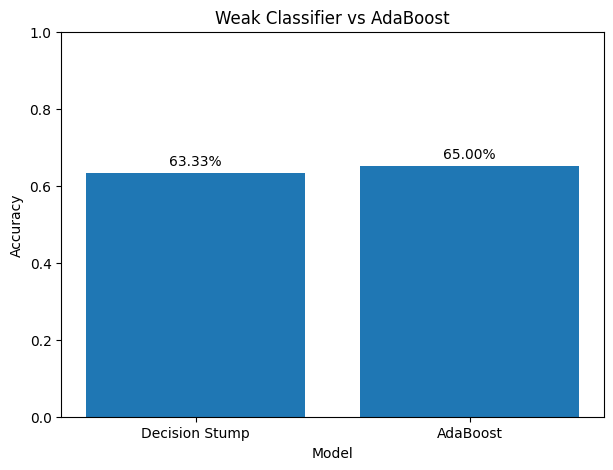

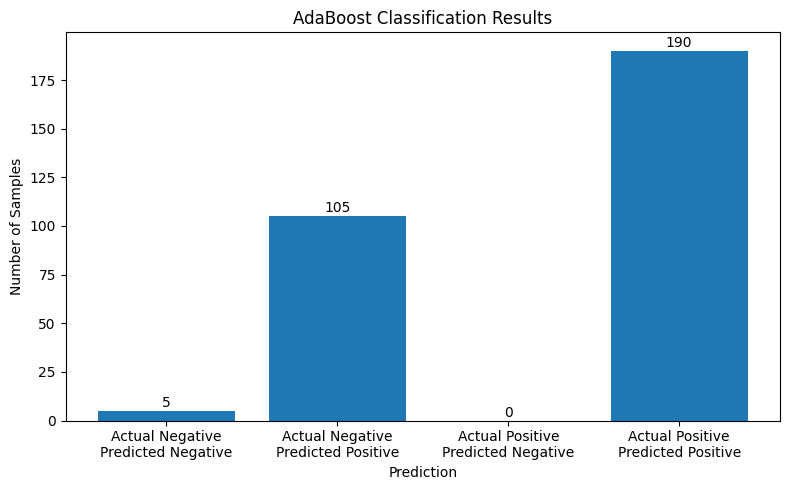

In [1]:
# PRACTICAL 4: ADABOOST ENSEMBLE LEARNING
# Dataset: Order Details.csv

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Order Details.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# 2. Create Binary Target

df["Profit_Class"] = (df["Profit"] > 0).astype(int)

print("\nProfit Class Distribution:")
print(df["Profit_Class"].value_counts())

# 3. Select Features

X = df[["Amount", "Quantity"]]
y = df["Profit_Class"]

# 4. Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# 5. Individual Weak Classifier

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

weak_classifier.fit(X_train, y_train)

weak_pred = weak_classifier.predict(X_test)

weak_accuracy = accuracy_score(
    y_test,
    weak_pred
)

print("\nWeak Classifier Accuracy:",
      round(weak_accuracy * 100, 2), "%")

# 6. Create AdaBoost Model

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# 7. Train AdaBoost

ada_model.fit(X_train, y_train)

print("\nAdaBoost model trained successfully!")

# 8. Prediction

ada_pred = ada_model.predict(X_test)

# 9. Evaluate AdaBoost

ada_accuracy = accuracy_score(
    y_test,
    ada_pred
)

print("\nAdaBoost Accuracy:",
      round(ada_accuracy * 100, 2), "%")

print("\nClassification Report:")

print(classification_report(
    y_test,
    ada_pred,
    target_names=["Negative Profit", "Positive Profit"]
))

# 10. Compare Models

print("\nMODEL COMPARISON")

print(
    "Decision Stump Accuracy:",
    round(weak_accuracy * 100, 2),
    "%"
)

print(
    "AdaBoost Accuracy:",
    round(ada_accuracy * 100, 2),
    "%"
)

# 11. Accuracy Comparison Graph

models = [
    "Decision Stump",
    "AdaBoost"
]

accuracies = [
    weak_accuracy,
    ada_accuracy
]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Weak Classifier vs AdaBoost")
plt.ylim(0, 1)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value*100:.2f}%",
        ha="center"
    )

plt.show()

# 12. AdaBoost Simple Confusion Matrix Plot

cm = confusion_matrix(y_test, ada_pred)

labels = [
    "Actual Negative\nPredicted Negative",
    "Actual Negative\nPredicted Positive",
    "Actual Positive\nPredicted Negative",
    "Actual Positive\nPredicted Positive"
]

values = [
    cm[0, 0],
    cm[0, 1],
    cm[1, 0],
    cm[1, 1]
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.xlabel("Prediction")
plt.ylabel("Number of Samples")
plt.title("AdaBoost Classification Results")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()